# Examen Práctico ISI
Autor: Melanie Buenaño

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
from google.colab import files

archivo = files.upload()

Saving real_estate_ecuador_200k.csv to real_estate_ecuador_200k (1).csv


In [54]:
df = pd.read_csv("real_estate_ecuador_200k.csv")

In [55]:
df.head()

,Titulo,Precio,Provincia,Lugar,Num. dormitorios,Num. banos,Area,Num. garages
0,Rento Suite 75 metros sector Republica del Sal...,395.66,Pichincha,"Pichincha, Av. Portugal & Av República de El S...",1.0,2.0,65,1.0
1,“Rento departamento en sector la Carolina”,773.69,Pichincha,"Pichincha, Catalina de Aldaz & Av. Portugal, Q...",2.0,2.0,88,1.0
2,Se Renta Amplio Departamento en el Sector de l...,616.94,Pichincha,"Pichincha, Marcos Jofre, Quito, Ecuador",4.0,4.0,214,1.0
3,Hermoso departamento de arriendo de oportunida...,286.69,Pichincha,"Pichincha, De la Prensa Y del Maestro, Quito, ...",2.0,2.0,98,1.0
4,"EN RENTA DEPARTAMENTO, CONJUNTO DIVINO NIÑO",131.54,Pichincha,"Pichincha, Turubamaba, Ecuador",3.0,2.0,53,NaN


In [56]:
df.columns

Index(['Titulo', 'Precio', 'Provincia', 'Lugar', 'Num. dormitorios',
       'Num. banos', 'Area', 'Num. garages'],
      dtype='object')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Titulo            200000 non-null  object 
 1   Precio            200000 non-null  float64
 2   Provincia         200000 non-null  object 
 3   Lugar             200000 non-null  object 
 4   Num. dormitorios  146845 non-null  float64
 5   Num. banos        165015 non-null  float64
 6   Area              200000 non-null  int64  
 7   Num. garages      142163 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 12.2+ MB


In [58]:
df.describe()

,Precio,Num. dormitorios,Num. banos,Area,Num. garages
count,200000.000000,146845.000000,165015.000000,200000.00000,142163.000000
mean,732.351461,2.504144,2.212377,579.01968,1.888691
std,870.573142,1.166590,1.193415,8915.40402,2.959052
min,7.220000,1.000000,1.000000,10.00000,0.000000
25%,371.770000,2.000000,1.000000,73.00000,1.000000
50%,510.490000,3.000000,2.000000,101.00000,1.000000
75%,728.642500,3.000000,3.000000,146.00000,2.000000
max,11062.330000,11.000000,11.000000,229852.00000,35.000000


In [59]:
# Eliminar filas duplicadas
df = df.drop_duplicates()

# Eliminar espacios al inicio y final de los textos
df["Provincia"] = df["Provincia"].str.strip()
df["Lugar"] = df["Lugar"].str.strip()
df["Titulo"] = df["Titulo"].str.strip()

# Eliminar registros sin precio o área
df = df.dropna(subset=["Precio", "Area"])

# Eliminar registros con precio o área igual o menor a cero
df = df[(df["Precio"] > 0) & (df["Area"] > 0)]

# Rellenar valores faltantes en dormitorios, baños y garajes
df["Num. dormitorios"] = df["Num. dormitorios"].fillna(0)
df["Num. banos"] = df["Num. banos"].fillna(0)
df["Num. garages"] = df["Num. garages"].fillna(0)

print("Registros después de la limpieza:", len(df))

Registros después de la limpieza: 199737


In [60]:
df["Titulo"].sample(20)

,Titulo
47932,Rento cómodo departamento sector Los Laureles
178933,LOCAL DE ARRIENDO EN LAS CASAS QUITO
188369,Hermoso departamento de arriendo amoblado sect...
74635,Departamento con Terraza Privada. Sector Mall ...
111261,Suite Amoblada de Lujo en la Shyris
162762,Departamento amoblado de Renta en la Coruña
114911,"SUITE AMOBLADA DE ARRIENDO , SECTOR LA CAROLINA"
8818,"Villa En El Sur De Guayaquil, Ciudadela Del IE..."
124961,Hermosa suite amoblada de arriendo de oportuni...
175504,Tv: Se Renta suite vacia Sector El Inca


In [61]:
df["Titulo"].sample(20)

,Titulo
46003,En Renta Lujosa Suite ubicada en el hotel MARR...
89980,"Quito Tenis, Exclusivo y bello depto de 90 M2"
134265,LOCAL EN RENTA A ESTRENAR DE 26M2 (EDF. AMELIA...
97731,Alquilo 2 Departamentos grandes de 4 dormitori...
145405,LOCAL DE ARRIENDO EN LAS CASAS QUITO
145739,SE ARRIENDA MINIDEPARTAMENTO NORTE DE QUITO
71310,"Rento Casa Hermosa, Cumbaya, Seguridad, Conjun..."
98385,Alquiler dpto. totalmente amoblado
74151,ALQUILO OFICINA CON AIRE ACONDICIONADO EN KENN...
155441,OFICINA DE ARRIENDO SECTOR LA MARISCAL


In [62]:
# Convertir el título a minúsculas para facilitar la búsqueda
df["Titulo"] = df["Titulo"].str.lower()

# Función para identificar el tipo de propiedad
def obtener_tipo(titulo):

    if "departamento" in titulo:
        return "Departamento"
    elif "suite" in titulo:
        return "Suite"
    elif "casa" in titulo:
        return "Casa"
    elif "local" in titulo:
        return "Local Comercial"
    elif "oficina" in titulo:
        return "Oficina"
    elif "bodega" in titulo:
        return "Bodega"
    elif "terreno" in titulo:
        return "Terreno"
    elif "quinta" in titulo:
        return "Quinta"
    elif "edificio" in titulo:
        return "Edificio"
    else:
        return "Otro"

# Crear la nueva columna
df["Tipo"] = df["Titulo"].apply(obtener_tipo)

# Verificar
df[["Titulo","Tipo"]].head(10)

,Titulo,Tipo
0,rento suite 75 metros sector republica del sal...,Suite
1,“rento departamento en sector la carolina”,Departamento
2,se renta amplio departamento en el sector de l...,Departamento
3,hermoso departamento de arriendo de oportunida...,Departamento
4,"en renta departamento, conjunto divino niño",Departamento
5,hermoso departamento remodelado centro norte,Departamento
6,rento casa muy moderna y elegante tanda,Casa
7,departamento de 3 dormitorios en ponceano,Departamento
8,hermoso departamento de arriendo amoblado sect...,Departamento
9,departamento en guayaquil en ciudadel alborada...,Departamento


# **Perspectiva Financiera**
---



In [63]:
# 1. Precio promedio de alquiler (General)
precio_general = df["Precio"].mean()

# 2. Precio promedio por ciudad (Lugar)
precio_ciudad = df.groupby("Lugar")["Precio"].mean().reset_index()
precio_ciudad.columns = ["Ciudad", "Precio Promedio"]

# 3. Costo promedio por metro cuadrado
df["Costo_m2"] = df["Precio"] / df["Area"]
costo_promedio_m2 = df["Costo_m2"].mean()

# 4. Rango de precios (Mínimo, Máximo y Promedio) por provincia
rango_precios = (
    df.groupby("Provincia")["Precio"]
      .agg(Minimo="min", Maximo="max", Promedio="mean")
      .reset_index()
)

print(f"Precio Promedio General: ${precio_general:,.2f}\n")

print("Precio Promedio por Ciudad:")
print(precio_ciudad)

print("\nCosto Promedio por Metro Cuadrado:")
print(f"${costo_promedio_m2:,.2f} por m²")

print("\nRango de Precios por Provincia:")
print(rango_precios)

Precio Promedio General: $732.86

Precio Promedio por Ciudad:
                                                Ciudad  Precio Promedio
0               Cotopaxi, Latacunga, Cotopaxi, Ecuador      3697.685799
1                         Cotopaxi, Latacunga, Ecuador       118.795973
2                  El Oro, El Cambio, Machala, Ecuador       124.256523
3                 El Oro, Parroquia El Cambio, Machala       124.458032
4    Esmeraldas, Av. Club del Pacífico, Tonsupa, Ec...       508.361152
..                                                 ...              ...
300                 Pichincha, Whymper, Quito, Ecuador       554.557651
301                 Pichincha, Yaruquí, Quito, Ecuador       450.745025
302                                Pichincha, iñaquito       549.872578
303                           Pichincha, poceano quito       448.353573
304                      Santa Elena, Chanduy, Ecuador         8.968586

[305 rows x 2 columns]

Costo Promedio por Metro Cuadrado:
$5.89 por m²



# **Perspectiva de Producto**

---



In [64]:
# Eliminar registros sin número de dormitorios
df_producto = df.dropna(subset=["Num. dormitorios"]).copy()

# 1. Distribución por Tipo de Propiedad
distribucion_tipo = (
    df["Tipo"]
    .value_counts()
    .reset_index()
)
distribucion_tipo.columns = ["Tipo de Propiedad", "Cantidad"]

# 2. Tamaño promedio de propiedades por provincia
tamano_promedio = (
    df.groupby("Provincia")["Area"]
      .mean()
      .reset_index()
)

tamano_promedio.columns = ["Provincia", "Área Promedio (m²)"]

# 3. Precio promedio por número de habitaciones
precio_habitaciones = (
    df_producto.groupby("Num. dormitorios")["Precio"]
               .mean()
               .sort_index()
               .reset_index()
)

precio_habitaciones.columns = ["Habitaciones", "Precio Promedio"]

# Calcular el Premium por habitación adicional
precio_habitaciones["Premium"] = (
    precio_habitaciones["Precio Promedio"].diff()
)

print("Distribución por Tipo de Propiedad")
print(distribucion_tipo)

print("\nTamaño Promedio de Propiedades por Provincia")
print(tamano_promedio)

print("\nPremium por Habitación Adicional")
print(precio_habitaciones)

Distribución por Tipo de Propiedad
  Tipo de Propiedad  Cantidad
0      Departamento     86343
1             Suite     24610
2           Oficina     23068
3   Local Comercial     21254
4              Casa     20159
5              Otro     16750
6            Bodega      4666
7           Terreno      1203
8            Quinta       869
9          Edificio       815

Tamaño Promedio de Propiedades por Provincia
     Provincia  Área Promedio (m²)
0     Cotopaxi           72.560890
1       El Oro         5947.770492
2   Esmeraldas          110.329588
3       Guayas          103.359699
4     Imbabura          140.670025
5     Los Rios           88.954899
6       Manabí          199.649038
7     Orellana           28.007317
8    Pichincha          166.932642
9  Santa Elena       199727.401515

Premium por Habitación Adicional
    Habitaciones  Precio Promedio      Premium
0            0.0      1001.784603          NaN
1            1.0       584.249067  -417.535536
2            2.0       496.88

# **Perspectiva Geográfica**

---



In [65]:
# Trabajar con registros válidos
df_geo = df[(df["Precio"] > 0)].copy()

# 1. Top 5 ciudades (Lugar) más caras
top5_ciudades = (
    df_geo.groupby("Lugar")["Precio"]
          .mean()
          .sort_values(ascending=False)
          .head(5)
          .reset_index()
)

top5_ciudades.columns = ["Ciudad", "Precio Promedio"]

# 2. Concentración de la oferta por ciudad
concentracion_oferta = (
    df_geo.groupby("Lugar")
          .size()
          .reset_index(name="Cantidad de Propiedades")
          .sort_values(by="Cantidad de Propiedades", ascending=False)
)

concentracion_oferta.columns = ["Ciudad", "Cantidad de Propiedades"]

print("Top 5 Ciudades Más Caras")
print(top5_ciudades)

print("\nConcentración de la Oferta por Ciudad")
print(concentracion_oferta)

Top 5 Ciudades Más Caras
                                            Ciudad  Precio Promedio
0  Pichincha, Avenida 10 de Agosto, Quito, Ecuador      9023.844069
1                           Manabí, Manta, Ecuador      6503.102091
2            Pichincha, La Delicia, Quito, Ecuador      4999.131409
3               Pichincha, Guamaní, Quito, Ecuador      3887.606034
4           Cotopaxi, Latacunga, Cotopaxi, Ecuador      3697.685799

Concentración de la Oferta por Ciudad
                                                Ciudad  \
259           Pichincha, Ponceano Alto, Quito, Ecuador   
280           Pichincha, Sangolqui, Sangolquí, Ecuador   
171               Pichincha, El Bosque, Quito, Ecuador   
269             Pichincha, Quito Tenis, Quito, Ecuador   
174  Pichincha, El Colibrí, Avenida General Rumiñah...   
..                                                 ...   
184  Pichincha, Gonzalez Suarez, Quito 170517, Ecuador   
3                 El Oro, Parroquia El Cambio, Machala   
125   

# **Segmentación de Mercado (Económico / Medio / Lujo)**

---




In [66]:
Q1 = df['Precio'].quantile(0.25)
Q3 = df['Precio'].quantile(0.75)

def clasificar_inmueble(precio):
    if precio < Q1:
        return "Económico"
    elif precio > Q3:
        return "Lujo"
    else:
        return "Medio"

df['Tipo_de_Inmueble'] = df['Precio'].apply(clasificar_inmueble)

print("Segmentación completada con éxito.")
print(df['Tipo_de_Inmueble'].value_counts())

Segmentación completada con éxito.
Tipo_de_Inmueble
Medio        99871
Lujo         49933
Económico    49933
Name: count, dtype: int64


# **DASHBOARD DE INTELIGENCIA DE NEGOCIOS**

---



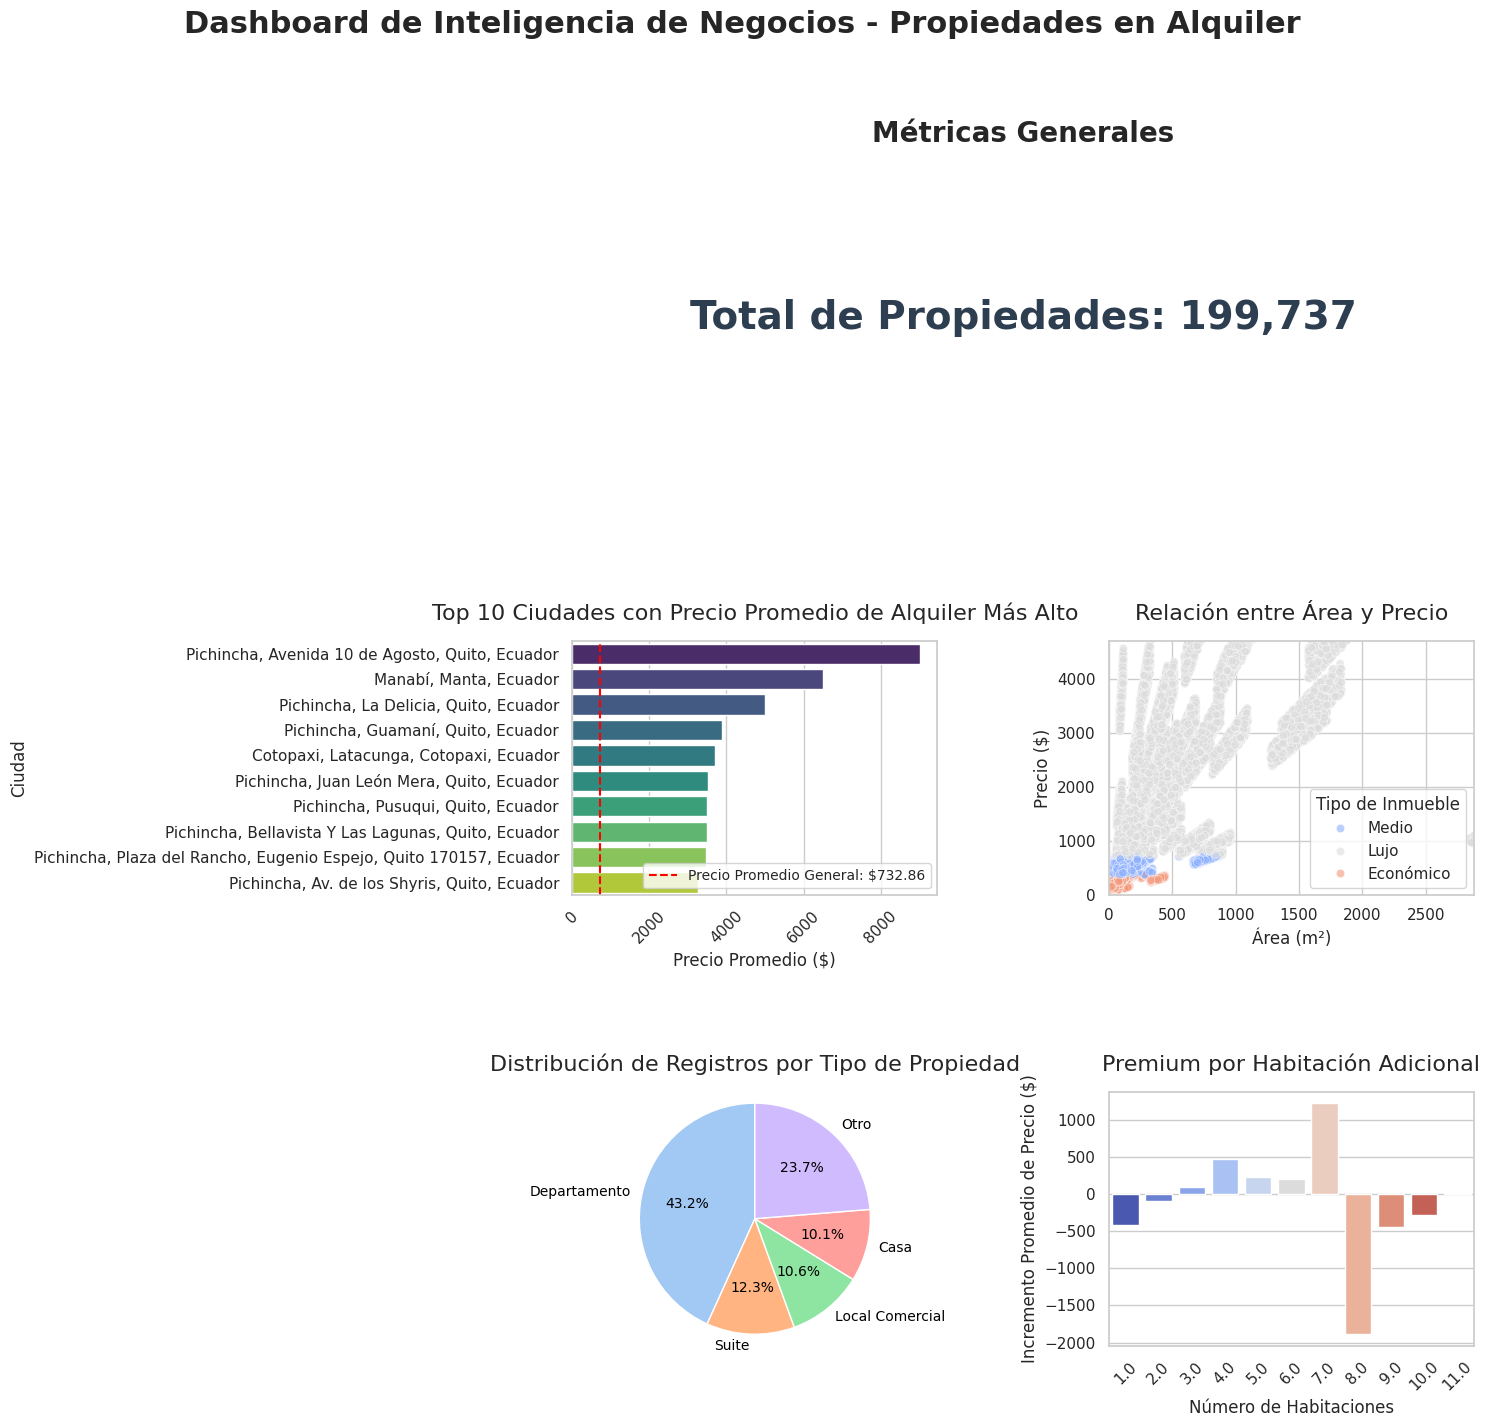

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")

plt.figure(figsize=(15, 15))
plt.suptitle('Dashboard de Inteligencia de Negocios - Propiedades en Alquiler', fontsize=22, fontweight='bold', y=0.98)

# 1. Total de propiedades
ax0 = plt.subplot(3, 2, (1, 2))

ax0.text(0.5, 0.5, f"Total de Propiedades: {len(df):,}", ha='center', va='center', fontsize=28, color='#2C3E50', fontweight='bold', fontfamily='sans-serif')
ax0.set_title('Métricas Generales', fontsize=20, pad=35, ha='center', fontweight='bold', fontfamily='sans-serif')
ax0.axis('off')

# 2. Gráfico de barras de Precio promedio de alquiler (General y por Ciudad)
top_n_cities = 10
city_prices_display = precio_ciudad.sort_values(by='Precio Promedio', ascending=False).head(top_n_cities)

ax1 = plt.subplot(3, 2, 3)
sns.barplot(x='Precio Promedio', y='Ciudad', data=city_prices_display, palette='viridis', ax=ax1, hue='Ciudad', legend=False)
ax1.axvline(precio_general, color='red', linestyle='--', label=f'Precio Promedio General: ${precio_general:,.2f}')
ax1.set_title('Top 10 Ciudades con Precio Promedio de Alquiler Más Alto', fontsize=16, pad=15)
ax1.set_xlabel('Precio Promedio ($)', fontsize=12)
ax1.set_ylabel('Ciudad', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend(loc='lower right', fontsize=10)

# 3. Gráfico de dispersión de la relación entre Área y Precio
ax2 = plt.subplot(3, 2, 4)
sns.scatterplot(x='Area', y='Precio', data=df, alpha=0.6, hue='Tipo_de_Inmueble', palette='coolwarm', ax=ax2)
ax2.set_title('Relación entre Área y Precio', fontsize=16, pad=15)
ax2.set_xlabel('Área (m²)', fontsize=12)
ax2.set_ylabel('Precio ($)', fontsize=12)

ax2.set_xlim(left=0, right=df['Area'].quantile(0.99))
ax2.set_ylim(bottom=0, top=df['Precio'].quantile(0.99))
ax2.legend(title='Tipo de Inmueble')

# 4. Gráfico de pastel de conteo de registros por Tipo
specific_types = ['Casa', 'Departamento', 'Suite', 'Local Comercial']
distribucion_filtered = distribucion_tipo[distribucion_tipo['Tipo de Propiedad'].isin(specific_types)]

other_count = distribucion_tipo[~distribucion_tipo['Tipo de Propiedad'].isin(specific_types)]['Cantidad'].sum()
if other_count > 0:
    distribucion_filtered = pd.concat([
        distribucion_filtered,
        pd.DataFrame([{'Tipo de Propiedad': 'Otro', 'Cantidad': other_count}])
    ], ignore_index=True)

ax3 = plt.subplot(3, 2, 5) # Third row, first column
ax3.pie(distribucion_filtered['Cantidad'], labels=distribucion_filtered['Tipo de Propiedad'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel')[0:len(distribucion_filtered)], pctdistance=0.6, textprops={'color': 'black', 'fontsize': 10})
ax3.set_title('Distribución de Registros por Tipo de Propiedad', fontsize=16, pad=15)
ax3.axis('equal')

# 5. Gráfico de Premium por Habitación Adicional
ax4 = plt.subplot(3, 2, 6)

precio_habitaciones_plot = precio_habitaciones.dropna(subset=['Premium'])

sns.barplot(x='Habitaciones', y='Premium', data=precio_habitaciones_plot, palette='coolwarm', ax=ax4, hue='Habitaciones', legend=False)
ax4.set_title('Premium por Habitación Adicional', fontsize=16, pad=15)
ax4.set_xlabel('Número de Habitaciones', fontsize=12)
ax4.set_ylabel('Incremento Promedio de Precio ($)', fontsize=12)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=5, w_pad=5)